In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('df_final.csv', encoding = 'latin1')

df.sample(6)

,Unnamed: 0,pid,year,age,meno,size,grade,nodes,pgr,er,...,chemo,rtime,recur,dtime,death,status,rtime_yrs,treatment,dtime_yrs,survival_probability%
2167,2167,2186,1991,37,0,20-50,3,5,37,8,...,1,762,1,1454,1,1,2.086242,placebo,3.983562,0.668756
76,76,77,1985,66,1,<=20,2,0,247,77,...,0,4320,0,4320,0,0,11.827515,drugA,11.835616,0.493670
283,283,287,1990,37,0,<=20,3,0,0,2,...,0,3237,0,3237,0,0,8.862423,placebo,8.868493,0.551682
2050,2050,2069,1987,63,1,20-50,2,0,69,31,...,0,2661,1,2753,1,1,7.285421,drugA,7.542466,0.569794
762,762,771,1983,57,1,>50,3,0,14,8,...,0,5162,0,5162,0,0,14.132786,drugA,14.142466,0.464819
1974,1974,1993,1988,60,1,20-50,3,1,117,714,...,0,1263,1,3427,0,0,3.457906,drugA,9.389041,0.543219


# Will Implement Multiple Machine Learning Models to Predict a Patient's Survival Time based on their current Attributes/Symptoms/Medical Measures.

## Gradient Boosting will be most Focused on.

In [3]:
# XGBoost - Gradient Boosting
# Builds one Tree at a Time; each Tree focuses on Correcting the Errors of the Previous Tree
# Final Result: Weighted Sum of all Trees

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, root_mean_squared_error as rmse, mean_absolute_error as mae, r2_score as r2
from sklearn.preprocessing import StandardScaler # No need for a RobustScaler (Optimal for Handling Outliers)

In [8]:
# Let's Build the Model

X = pd.concat([pd.get_dummies(df[['size', 'meno', 'hormon', 'chemo', 'grade']]), df[['rtime', 'pgr', 'er', 'age']]], axis = 1)
y = df['dtime']*100

# Standardizing the Features
sc = StandardScaler()

X = sc.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

# Hyperparameter Tuning to Optimize the XGBoost Model

from sklearn.model_selection import GridSearchCV

# Defining the Parameter Grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

# Performing Grid Search
grid_search = GridSearchCV(XGBRegressor(objective = 'reg:squarederror'), param_grid, cv = 3, scoring = 'neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Printing the Best Parameters
print("Best Parameters:", grid_search.best_params_)

# Let's get the XGBoost Model going - Using the Optimal Parameters as Determined^
xgreg = XGBRegressor(objective = 'reg:squarederror', n_estimators = 300, learning_rate = 0.01,
                    max_depth = 3, subsample = 0.8, colsample_bytree = 0.8) # Using the Optimal Hyperparameters for the Model

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [9]:
# Fitting the Model

xgreg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
# Making some Predictions

y_pred = xgreg.predict(X_test)

# Evaluating the Gradient Boosting Regression Model

print("Mean Squared Error:", mse(y_test, y_pred))
print("Root Mean Squared Error:", rmse(y_test, y_pred))
print("Mean Absolute Error:", mae(y_test, y_pred)) # On Average, this Model's Predictions for Survival Probability (%) are off by about 3.92 Percentage points - above or below the Actual
print("R-Squared Score:", r2(y_test, y_pred)*100) # So, the Model explains 70% of the Variance in Survival Probability (%) - Decent

Mean Squared Error: 4165568256.0
Root Mean Squared Error: 64541.21484375
Mean Absolute Error: 44872.72265625
R-Squared Score: 75.0555694103241


<Figure size 2400x800 with 0 Axes>

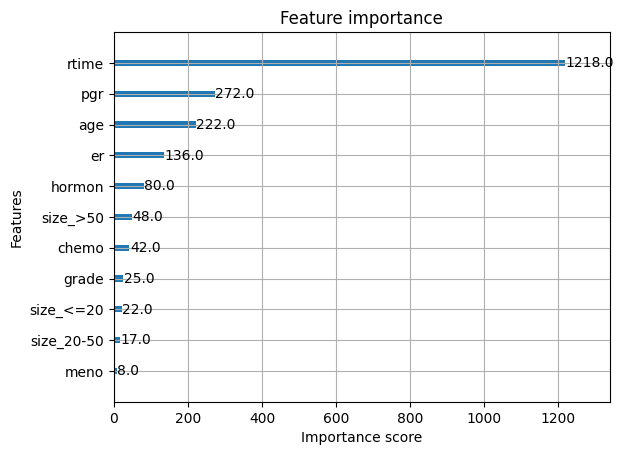

In [15]:
# Details of the Gradient Boosting XGBoost Model

from xgboost import plot_importance

actual_feature_names = pd.concat([pd.get_dummies(df[['size', 'meno', 'hormon', 'chemo', 'grade']]), df[['rtime', 'pgr', 'er', 'age']]], axis = 1).columns.tolist()

# Assign the dynamically obtained feature names to the booster
xgreg.get_booster().feature_names = actual_feature_names

plt.figure(figsize = (24, 8))
plot_importance(xgreg)
plt.show() # Predicting Survival Probability (%)

# Relapse Time (Years) is the most Important Feature in the Model, Followed by Progesterone Receptors and then Age, etc.
# Being in Menopause is Actually of Least Importance in Predicting Survival Probability (%)

In [16]:
# Building more Models, Evaluating, and then Comparing all

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators = 300, n_jobs = -1),
    "Gradient Boosting (XGBoost) Regressor": xgreg
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Evaluate
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "RMSE": round(rmse, 2), "MSE": round(mse, 2),
                    "MAE": round(mae, 2), "R2 Score": round(r2*100, 2)})

# Let's look at & Evaluate each Model and also Compare it to Others
results_df = pd.DataFrame(results).sort_values(by = "R2 Score", ascending = False)
display(results_df)

# XGBoost (Gradient Boosting) Model is still on top!

,Model,RMSE,MSE,MAE,R2 Score
3,Gradient Boosting (XGBoost) Regressor,64541.21,4.165568e+09,44872.72,75.06
0,Linear Regression,66078.76,4.366403e+09,47139.19,73.85
2,Random Forest Regressor,68079.55,4.634825e+09,45569.17,72.25
1,Decision Tree Regressor,93828.20,8.803732e+09,56840.21,47.28




---


Credit: https://github.com/xbeat and his `Machine-Learning` Repository.

# OPTIONAL for the Future: Saving the XGBoost Model (can save the Other ones too, but I want to Focus on further Improving and then Using the XGBoost Regressor Model) for Future Use & Deployment:

Saving and Loading XGBoost Models.

After Training your XGBoost model, you can save it for future use without retraining. This is particularly useful for deploying models in production environments.


In [ ]:
# import joblib

# Saving the Model
# joblib.dump(xgreg, 'xgboost_model.joblib')

# FUTURE USAGE: Loading the Model
# loaded_model = joblib.load('xgboost_model.joblib')

# Defining a Sample new Patient's Attributes
# new_patient_data = {
#     'size': '<=20',
#     'meno': 0, # 0 = Premenopausal, 1 = Postmenopausal
#     'hormon': 0, # 0 = No, 1 = Yes
#     'chemo': 0, # 0 = No, 1 = Yes
#     'grade': 2, # Differentiation Grade (Cancer Stage): 2 or 3
#     'rtime_yrs': 5.0,
#     'pgr': 100, # Progesterone Receptors (fmol/l)
#     'er': 200, # Estrogen Receptors (fmol/l)
#     'age': 50
# }

# # 2. Creating a DataFrame from this new Data point
# new_df = pd.DataFrame([new_patient_data])

# # Identifying Categorical and Numerical columns from the original setup
# categorical_cols = ['size', 'meno', 'hormon', 'chemo', 'grade']
# numerical_cols = ['rtime_yrs', 'pgr', 'er', 'age']

# # 3. One-Hot Encoding Categorical Features for new data
# new_df_categorical_encoded = pd.get_dummies(new_df[categorical_cols], columns=categorical_cols)

# # 4. Aligning the columns of "new_df_categorical_encoded" with the Training data's Dummy columns
# # The original X columns were obtained from "xgreg.get_booster().feature_names"
# original_X_columns_for_dummies = [
#     'size_20-50', 'size_<=20', 'size_>50',
#     'meno_0', 'meno_1',
#     'hormon_0', 'hormon_1',
#     'chemo_0', 'chemo_1',
#     'grade_2', 'grade_3'
# ]

# # Reindexing to Ensure all Original Dummy columns are present and in the correct order
# new_df_categorical_aligned = new_df_categorical_encoded.reindex(columns = original_X_columns_for_dummies, fill_value = 0)

# # 5. Concatenating with Numerical features
# new_X_processed = pd.concat([new_df_categorical_aligned, new_df[numerical_cols]], axis = 1)

# # Ensuring the Final order of columns matches the Original X used for Training
# # (from "xgreg.get_booster().feature_names")
# final_X_columns = [
#     'size_20-50', 'size_<=20', 'size_>50',
#     'meno_0', 'meno_1',
#     'hormon_0', 'hormon_1',
#     'chemo_0', 'chemo_1',
#     'grade_2', 'grade_3',
#     'rtime_yrs', 'pgr', 'er', 'age'
# ]

# new_X_processed = new_X_processed[final_X_columns]

# # 6. Scaling the new Data using the *fitted* StandardScaler (sc)
# new_X_scaled = sc.transform(new_X_processed)

# # 7. Making a Prediction
# new_prediction = loaded_model.predict(new_X_scaled)

# print(f"Predicted Survival Probability for the new Patient, using the Loaded XGBoost Model: {new_prediction[0]:.2f}%")